In [1]:
from google.colab import files
uploaded = files.upload()

Saving t10k-images-idx3-ubyte to t10k-images-idx3-ubyte


In [2]:
from google.colab import files
uploaded = files.upload()

Saving t10k-labels-idx1-ubyte to t10k-labels-idx1-ubyte


In [3]:
from google.colab import files
uploaded = files.upload()

Saving train-images-idx3-ubyte to train-images-idx3-ubyte


In [4]:
from google.colab import files
uploaded = files.upload()

Saving train-labels-idx1-ubyte to train-labels-idx1-ubyte


Files in directory:
['.config', 't10k-images-idx3-ubyte', 't10k-labels-idx1-ubyte', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte', 'sample_data']
Train shape: (60000, 784)
Test shape: (10000, 784)


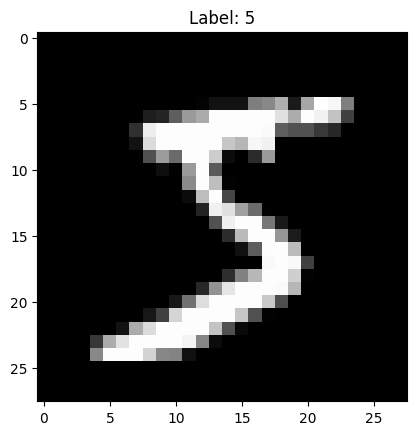


Training Logistic Regression...
Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       175
           1       0.94      0.97      0.96       234
           2       0.87      0.83      0.85       219
           3       0.85      0.83      0.84       207
           4       0.89      0.90      0.90       217
           5       0.81      0.82      0.82       179
           6       0.87      0.92      0.90       178
           7       0.85      0.85      0.85       205
           8       0.83      0.79      0.81       192
           9       0.82      0.84      0.83       194

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



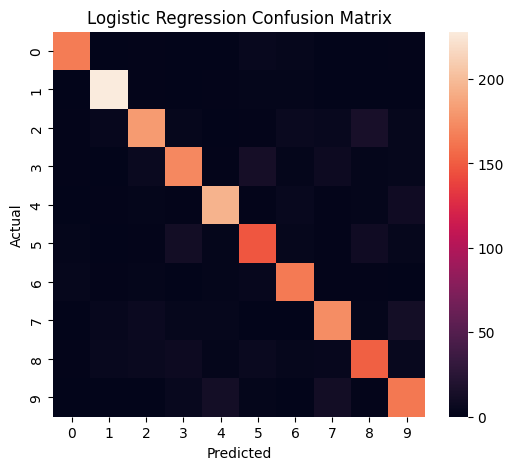


Training KNN...
Accuracy: 0.9235
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       175
           1       0.90      1.00      0.95       234
           2       0.98      0.89      0.93       219
           3       0.91      0.91      0.91       207
           4       0.94      0.94      0.94       217
           5       0.91      0.91      0.91       179
           6       0.95      0.97      0.96       178
           7       0.89      0.91      0.90       205
           8       0.95      0.80      0.87       192
           9       0.89      0.90      0.89       194

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



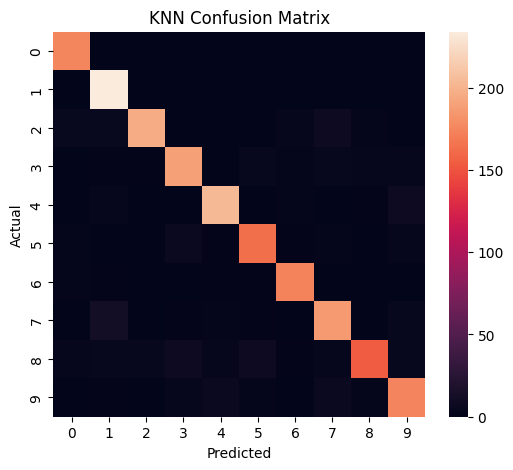


Training Decision Tree...
Accuracy: 0.773
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       175
           1       0.90      0.90      0.90       234
           2       0.78      0.77      0.77       219
           3       0.72      0.74      0.73       207
           4       0.78      0.76      0.77       217
           5       0.68      0.71      0.69       179
           6       0.83      0.75      0.79       178
           7       0.81      0.84      0.82       205
           8       0.63      0.60      0.62       192
           9       0.75      0.77      0.76       194

    accuracy                           0.77      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.77      0.77      0.77      2000



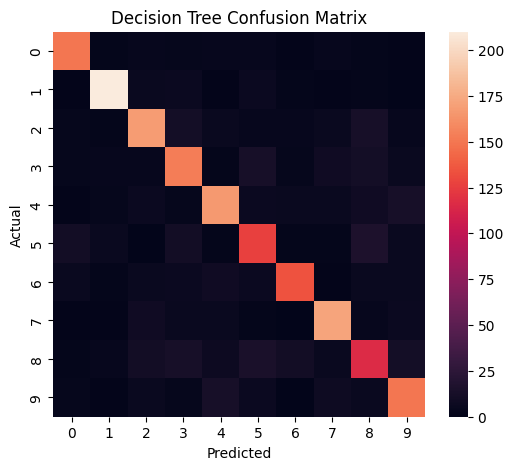


Training Random Forest...
Accuracy: 0.922
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       175
           1       0.98      0.98      0.98       234
           2       0.93      0.91      0.92       219
           3       0.94      0.92      0.93       207
           4       0.93      0.91      0.92       217
           5       0.93      0.93      0.93       179
           6       0.92      0.94      0.93       178
           7       0.92      0.90      0.91       205
           8       0.90      0.84      0.87       192
           9       0.84      0.89      0.86       194

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



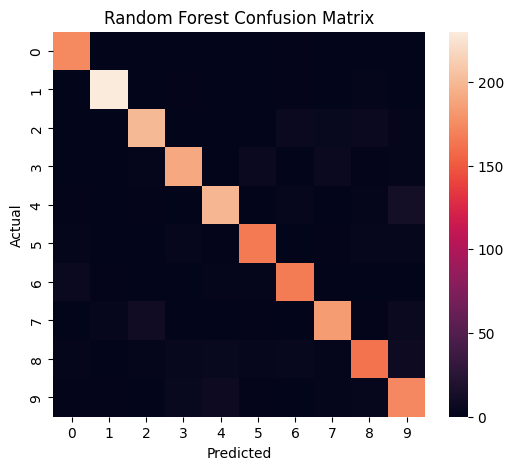


Final Results:
Logistic Regression: 0.87
KNN: 0.9235
Decision Tree: 0.773
Random Forest: 0.922


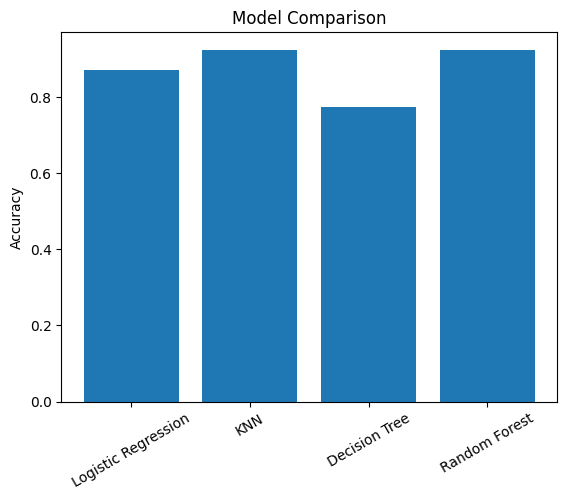

In [10]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# =========================
# 2. CHECK FILES
# =========================
print("Files in directory:")
print(os.listdir())

# =========================
# 3. LOAD FUNCTIONS
# =========================
def load_images(file_path):
    with open(file_path, 'rb') as f:
        f.read(16)  # skip header
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(-1, 28*28)

def load_labels(file_path):
    with open(file_path, 'rb') as f:
        f.read(8)  # skip header
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# =========================
# 4. LOAD DATA (CORRECT NAMES)
# =========================
X_train = load_images('train-images-idx3-ubyte')
y_train = load_labels('train-labels-idx1-ubyte')

X_test = load_images('t10k-images-idx3-ubyte')
y_test = load_labels('t10k-labels-idx1-ubyte')

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================
# 5. REDUCE DATA (FASTER)
# =========================
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# =========================
# 6. NORMALIZATION
# =========================
X_train = X_train / 255.0
X_test = X_test / 255.0

# =========================
# 7. SHOW SAMPLE IMAGE
# =========================
plt.imshow(X_train[0].reshape(28,28), cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# =========================
# 8. MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=50)
}

results = {}

# =========================
# 9. TRAIN & EVALUATE
# =========================
for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=False)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# =========================
# 10. FINAL RESULTS
# =========================
print("\nFinal Results:")
for model, acc in results.items():
    print(f"{model}: {acc}")

plt.figure()
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()